### 1. CONTEXTO Y FUENTE DE DATOS: DISECCIONANDO EL ADN TÁCTICO
Todo proyecto de *Storytelling* requiere una base de evidencia sólida. Para este análisis construimos nuestro propio ecosistema de datos a partir de la materia prima más granular del fútbol analítico: **la base de datos de eventos relacionales de StatsBomb**.

**El Alcance Competitivo**
El dataset abarca la élite del fútbol de selecciones, garantizando una muestra de máxima exigencia competitiva. Se incluyeron los datos completos de seis grandes torneos:
* Copa del Mundo de la FIFA (2018 y 2022)
* Eurocopa de la UEFA (2020, 2024)
* Copa América (2024)
* Copa Africana de Naciones (2023)

**La Granularidad Original: De la jugada al dato**
La base de datos original operaba mediante tablas relacionales complejas (Competencia -> Partido -> Evento). En su estado crudo, el sistema registraba cada acción individual en el campo, generando decenas de miles de filas por partido con columnas como `match_id`, `minute`, `second`, `player`, `position` y un diccionario masivo de más de 100 etiquetas técnicas detalladas (desde la parte del cuerpo usada en un pase, hasta si un tiro fue bloqueado o bajo presión).

---

### 2. INGENIERÍA DE DATOS: EL PIPELINE ESTADÍSTICO
Para transformar este océano de eventos aislados en la matriz matemática que alimenta nuestro modelo de *Machine Learning* (SOM), se diseñó un pipeline de preprocesamiento en tres fases críticas:

**Fase 1: Identificación a Nivel de Evento (Máscaras Booleanas)**
El primer paso consistió en limpiar el dataset de registros huérfanos (acciones sin jugador asignado) y traducir la narrativa del juego a lógica matemática. Se crearon variables de identificación (`True`/`False`) fila por fila para clasificar cada acción en tres grandes dimensiones tácticas:
* **Pases:** Se aislaron todos los intentos de pase para definir matemáticamente su éxito (ausencia de un resultado negativo en los registros), si el jugador estaba siendo acosado por el rival (`under_pressure`) y si logró ejecutar balones filtrados exitosos (`pass_through_ball`).
* **Tiros:** Se identificaron los remates, detectando cuáles terminaron en gol y estandarizando la métrica avanzada de *Expected Goals* (`xG`), rellenando con ceros cualquier acción sin valor probabilístico asignado.
* **Defensa:** Se etiquetaron las acciones de destrucción pura (intercepciones y recuperaciones de balón) y se desglosaron los duelos físicos, aislando específicamente la cantidad de duelos aéreos totales y ganados.

**Fase 2: Agregación de Volúmenes Absolutos**
Posteriormente, la base de datos se agrupó a nivel de jugador (`player`) y equipo (`team`). Se sumaron todas las acciones individuales para obtener volúmenes brutos por torneo: `partidos_jugados`, `pases_totales`, `influencia_total`, `recuperaciones_totales`, `faltas_recibidas`, entre otros, extrayendo también la posición más frecuente de cada futbolista.

**Fase 3: Estandarización y Control de Varianza**
Comparar a un jugador que disputó 7 partidos con uno que jugó solo 15 minutos genera un sesgo estadístico severo. Para evitar esto, se calcularon los minutos totales exactos de cada jugador y se aplicaron dos reglas fundamentales:
1. **Filtro de Rigor:** Se eliminaron de la muestra todos los jugadores con menos de **270 minutos jugados** (equivalente a 3 partidos completos), asegurando que el rendimiento analizado sea una tendencia real y no una anomalía por muestra pequeña.
2. **Proyección P90 y Ratios:** Se abandonaron los volúmenes absolutos para dar paso a métricas de eficiencia. Los datos se dividieron por los minutos jugados y se multiplicaron por 90 (ej. `Intercepciones P90`), creando tasas comparables universales. Además, se calcularon porcentajes de efectividad pura, como el % de Pases Exitosos o el % de Duelos Aéreos ganados.

---

### 3. LA MATRIZ DE DISEÑO: LAS 10 DIMENSIONES DEL JUEGO
Tras este riguroso procesamiento, el modelo SOM fue alimentado exclusivamente con las siguientes 10 variables estandarizadas, elegidas para capturar todas las fases del juego (creación, definición, posesión y destrucción):

1. **xG P90:** Volumen de peligro generado por el jugador cada 90 minutos.
2. **xG por Tiro:** Calidad promedio de las decisiones de remate (eficiencia).
3. **% Pases Bajo Presión:** Capacidad técnica para mantener la posesión en situaciones críticas de asedio.
4. **Asistencias a Tiro P90:** Frecuencia de creación de oportunidades (pases clave) para los compañeros.
5. **% Pases Exitosos:** Efectividad general y seguridad en la distribución del balón.
6. **Intercepciones P90:** Capacidad de lectura espacial y anticipación para cortar líneas de pase.
7. **% Duelos Aéreos:** Tasa de éxito y dominancia física en balones divididos por alto.
8. **Recuperaciones P90:** Intensidad y posicionamiento para obtener balones sueltos.
9. **Influencia Global P90:** Volumen total de intervenciones del jugador, reflejando su peso específico en la estructura del equipo.
10. **Faltas Recibidas P90:** Capacidad para retener el balón, desequilibrar y forzar infracciones.

*Con esta matriz validada y limpia, los datos dejaron de ser registros de eventos para convertirse en el ADN táctico cuantificable de cada futbolista, listo para ser interpretado por la Inteligencia Artificial.*

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cargar el dataset
df_resultados = pd.read_csv('Master_Dataset_Scouting (3).csv')

# 2. Filtrar para la narrativa de negocio
arquitectos = df_resultados[df_resultados['Arquetipo_SOM'] == 3].sort_values(by='Score_Jugador', ascending=False)

FileNotFoundError: [Errno 2] No such file or directory: 'Master_Dataset_Scouting (3).csv'

In [94]:
df_resultados.head()

,player,team,position,partidos_jugados,influencia_total,pases_totales,pases_exitosos_totales,pases_presion_totales,asistencias_tiro,tiros_totales,...,% Duelos Aéreos_Percentil,Recuperaciones P90_Crudo,Recuperaciones P90_MinMax,Recuperaciones P90_Percentil,Influencia Global P90_Crudo,Influencia Global P90_MinMax,Influencia Global P90_Percentil,Faltas Recibidas P90_Crudo,Faltas Recibidas P90_MinMax,Faltas Recibidas P90_Percentil
0,Aaron Mooy,Australia,Left Center Midfield,7,1284,425,339,73,12,4,...,85.636646,7.029096,0.680944,99.223602,176.967841,0.474463,89.208075,0.275651,0.053421,19.875776
1,Aaron Ramsey,Wales,Left Center Midfield,7,1074,267,207,53,5,8,...,63.082298,5.094340,0.493514,91.925466,151.981132,0.404340,76.708075,1.981132,0.383940,90.527950
2,Aaron Tshibola,Congo DR,Right Defensive Midfield,6,266,70,61,5,2,1,...,73.408385,1.306715,0.126588,15.217391,43.448276,0.099755,8.850932,0.163339,0.031655,12.344720
3,Abdelhamid Sabiri,Morocco,Left Center Midfield,5,242,58,46,11,2,4,...,73.408385,0.644391,0.062425,74.922360,51.980907,0.123701,85.636646,0.644391,0.124882,76.048137
4,Abdelkarim Hassan Al Haj Fadlalla,Qatar,Left Center Back,3,524,158,125,21,True,6,...,12.422360,3.898917,0.377708,17.274845,170.252708,0.455617,2.950311,1.299639,0.251868,35.481366


In [95]:
columns = df_resultados.columns.tolist()
num_columns = len(columns)
columns_per_row = 3
rows = (num_columns + columns_per_row - 1) // columns_per_row

print("List of Variables (3 Columns):")
for r in range(rows):
    row_display = []
    for c in range(columns_per_row):
        idx = r + c * rows
        if idx < num_columns:
            row_display.append(f"{columns[idx]:<35}") # Adjust padding as needed
        else:
            row_display.append("")
    print(" ".join(row_display))


List of Variables (3 Columns):
player                              Recuperaciones P90                  Asistencias a Tiro P90_MinMax      
team                                Influencia Global P90               Asistencias a Tiro P90_Percentil   
position                            Faltas Recibidas P90                % Pases Exitosos_Crudo             
partidos_jugados                    % Pases Bajo Presión                % Pases Exitosos_MinMax            
influencia_total                    xG por Tiro                         % Pases Exitosos_Percentil         
pases_totales                       % Pases Exitosos                    Intercepciones P90_Crudo           
pases_exitosos_totales              % Duelos Aéreos                     Intercepciones P90_MinMax          
pases_presion_totales               Arquetipo_SOM                       Intercepciones P90_Percentil       
asistencias_tiro                    Score_Jugador                       % Duelos Aéreos_Crudo            

In [96]:
# ==================================================================================
# CELDA MAESTRA: MOTOR DE ANÁLISIS DESCRIPTIVO (CON ÍNDICE 0-1, COLOR Y DOBLE RANKING)
# ==================================================================================

# 1. Cargar el Dataset Maestro
df_maestro = pd.read_csv('Master_Dataset_Scouting (3).csv')

# 2. Identificar las variables base
variables_tacticas = [
    'xG P90', 'xG por Tiro', '% Pases Bajo Presión', 'Asistencias a Tiro P90',
    '% Pases Exitosos', 'Intercepciones P90', '% Duelos Aéreos',
    'Recuperaciones P90', 'Influencia Global P90', 'Faltas Recibidas P90'
]

# 3. Definición de Códigos ANSI para colores
C_ROJO = '\033[91m'      # Ataque
C_AMARILLO = '\033[93m'  # Creación / Medios
C_VERDE = '\033[92m'     # Defensa
C_AZUL = '\033[94m'      # Global / Otras
C_RESET = '\033[0m'      # Resetear formato

mapa_colores = {
    'xG P90': C_ROJO, 'xG por Tiro': C_ROJO,
    '% Pases Bajo Presión': C_AMARILLO, 'Asistencias a Tiro P90': C_AMARILLO, '% Pases Exitosos': C_AMARILLO,
    'Intercepciones P90': C_VERDE, '% Duelos Aéreos': C_VERDE, 'Recuperaciones P90': C_VERDE,
    'Influencia Global P90': C_AZUL, 'Faltas Recibidas P90': C_AZUL
}

# 4. Calcular el Orden de Poder de los Clústeres
ranking_clusters = df_maestro.groupby('Arquetipo_SOM')['Score_Total_Global' if 'Score_Total_Global' in df_maestro.columns else 'Score_Jugador'].mean().sort_values(ascending=False).index.tolist()
print(f"✅ Motor inicializado. Orden de clústeres calculado de mayor a menor impacto: {ranking_clusters}")

# 4.5 MATRIZ DE RANKING INTER-CLÚSTER
cols_indice = [f'{var}_MinMax' for var in variables_tacticas]
medias_por_cluster = df_maestro.groupby('Arquetipo_SOM')[cols_indice].mean()
ranking_variables = medias_por_cluster.rank(ascending=False, method='min').astype(int)
total_clusters = len(ranking_clusters)
print(f"✅ Matriz de competitividad generada sobre {total_clusters} arquetipos.\n")


# 5. FUNCIÓN GENERADORA DEL REPORTE ULTRA-COMPLETO
def generar_reporte_cluster(df, cluster_id, posicion_ranking):
    df_cluster = df[df['Arquetipo_SOM'] == cluster_id]

    col_score_global = 'Score_Total_Global' if 'Score_Total_Global' in df.columns else 'Score_Jugador'
    impacto_global = df_cluster[col_score_global].mean()
    total_jugadores = len(df_cluster)

    print("="*105)
    print(f"🏆 RANKING GLOBAL #{posicion_ranking} | ANÁLISIS PROFUNDO DEL ARQUETIPO TÁCTICO: {cluster_id}")
    print("="*105)
    print(f"👥 Tamaño del grupo: {total_jugadores} jugadores")
    print(f"🌟 Índice Global del Clúster: {impacto_global:.2f} (Escala 0-1)")

    # A. DISTRIBUCIÓN POSICIONAL (Modificado: Top 4 y desglose de "Otros")
    print("\n📋 COMPOSICIÓN POSICIONAL (Etiquetas Nominales):")
    conteos_pos = df_cluster['position'].value_counts() # Changed 'Posicion_Nominal' to 'position'

    # Separar el Top 4 y el resto
    top_4_pos = conteos_pos.head(4)
    posiciones_restantes = conteos_pos.iloc[4:]
    otros_count = posiciones_restantes.sum() if len(conteos_pos) > 4 else 0
    num_otras_posiciones = len(posiciones_restantes)

    # Imprimir las 4 más frecuentes
    for pos, count in top_4_pos.items():
        porcentaje = (count / total_jugadores) * 100
        print(f"   ▪️ {pos:<28}: {count} jugadores ({porcentaje:.1f}%)")

    # Imprimir "Otros" con el conteo de posiciones distintas
    if otros_count > 0:
        porcentaje_otros = (otros_count / total_jugadores) * 100
        etiqueta_otros = f"Otros ({num_otras_posiciones} pos. distintas)"
        print(f"   ▪️ {etiqueta_otros:<28}: {otros_count} jugadores ({porcentaje_otros:.1f}%)")

    # B. DESGLOSE TÁCTICO ORDENADO POR RANKING Y LUEGO POR ÍNDICE
    print("\n📊 PERFIL ESTADÍSTICO DEL ARQUETIPO (Promedios del Grupo):")
    print(f"   {'Variable':<25} | {'Valor Real (Crudo)':<20} | {'Índice (0-1)':<12} | {'Ranking vs Resto'}")
    print("   " + "-"*85)

    resultados_variables = []
    for var in variables_tacticas:
        promedio_crudo = df_cluster[f'{var}_Crudo'].mean()
        promedio_indice = df_cluster[f'{var}_MinMax'].mean()
        media_torneo = df[f'{var}_MinMax'].mean()

        rango_inter_cluster = ranking_variables.loc[cluster_id, f'{var}_MinMax']

        resultados_variables.append({
            'nombre': var,
            'crudo': promedio_crudo,
            'indice': promedio_indice,
            'sobre_media': promedio_indice > media_torneo,
            'ranking': rango_inter_cluster
        })

    resultados_variables_ordenados = sorted(resultados_variables, key=lambda x: (x['ranking'], -x['indice']))

    for stat in resultados_variables_ordenados:
        indicador = "🟢" if stat['sobre_media'] else "🔴"
        color = mapa_colores.get(stat['nombre'], C_RESET)
        nombre_alineado = f"{stat['nombre']:<23}"
        nombre_coloreado = f"{color}{nombre_alineado}{C_RESET}"
        medalla = "🥇" if stat['ranking'] == 1 else "🥈" if stat['ranking'] == 2 else "🥉" if stat['ranking'] == 3 else "  "

        print(f"   {indicador} {nombre_coloreado} | {stat['crudo']:>18.2f} | {stat['indice']:>12.2f} | {medalla} #{stat['ranking']}/{total_clusters}")

    # C. LOS 4 JUGADORES MÁS DOMINANTES
    print("\n⭐ TOP 4 JUGADORES MÁS DOMINANTES DEL ECOSISTEMA:")
    top_4 = df_cluster.sort_values(by=col_score_global, ascending=False).head(4)

    has_equipo = 'Equipo' in df_cluster.columns
    for i, (_, row) in enumerate(top_4.iterrows(), start=1):
        nombre = row['player']
        pos_nom = row['position'] # Changed 'Posicion_Nominal' to 'position'
        indice_jugador = row[col_score_global]
        equipo = f" ({row['Equipo']})" if has_equipo else ""

        print(f"   {i}. 🏃 {nombre:<25} {equipo:<20} | Pos: {pos_nom:<15} | Índice: {indice_jugador:.2f}")

    print("="*105 + "\n")


✅ Motor inicializado. Orden de clústeres calculado de mayor a menor impacto: [11, 9, 8, 0, 3, 7, 5, 2, 1, 6, 4, 10]
✅ Matriz de competitividad generada sobre 12 arquetipos.



### 🧠 FAMILIA 1: EL EJE CREATIVO Y DE DESEQUILIBRIO
*El algoritmo agrupa aquí a los jugadores que asumen el peso de la transición ofensiva y la creación, diferenciando a los súper-clase absolutos de los perfiles de apoyo por las bandas.*

* **Arquetipo 11 ("Maestros y Desequilibrantes de Élite"):** El grupo de máximo rendimiento del torneo (+0.35 Scores). Liderado por figuras como Vela, Neymar y Verratti. Dominan la estadística con el 🥇 #1 en **Asistencias a Tiro P90** e **Influencia Global**. El modelo detecta que no solo arman el juego, sino que su nivel de amenaza es tan alto que son los que más **Faltas Reciben** del ecosistema.
* **Arquetipo 5 ("Asistidores de Complemento / Carrileros"):** Perfil de jugadores que mantienen una excelente capacidad creativa (🥈 #2 en Asistencias a Tiro) y una sólida resistencia a la presión, pero su *Influencia Global* cae respecto a la élite. Aportan fluidez por las bandas o como mediapuntas, pero no monopolizan el juego del equipo.

In [97]:
# Extracción de la Familia 1: El Eje Creativo y de Desequilibrio
print("\n" + "🧠 "*30)
generar_reporte_cluster(df_maestro, cluster_id=11, posicion_ranking=1)
generar_reporte_cluster(df_maestro, cluster_id=5, posicion_ranking=7)


🧠 🧠 🧠 🧠 🧠 🧠 🧠 🧠 🧠 🧠 🧠 🧠 🧠 🧠 🧠 🧠 🧠 🧠 🧠 🧠 🧠 🧠 🧠 🧠 🧠 🧠 🧠 🧠 🧠 🧠 
🏆 RANKING GLOBAL #1 | ANÁLISIS PROFUNDO DEL ARQUETIPO TÁCTICO: 11
👥 Tamaño del grupo: 78 jugadores
🌟 Índice Global del Clúster: 0.35 (Escala 0-1)

📋 COMPOSICIÓN POSICIONAL (Etiquetas Nominales):
   ▪️ Left Wing                   : 13 jugadores (16.7%)
   ▪️ Center Attacking Midfield   : 11 jugadores (14.1%)
   ▪️ Right Wing                  : 9 jugadores (11.5%)
   ▪️ Left Center Midfield        : 9 jugadores (11.5%)
   ▪️ Otros (12 pos. distintas)   : 36 jugadores (46.2%)

📊 PERFIL ESTADÍSTICO DEL ARQUETIPO (Promedios del Grupo):
   Variable                  | Valor Real (Crudo)   | Índice (0-1) | Ranking vs Resto
   -------------------------------------------------------------------------------------
   🟢 Asistencias a Tiro P90  |               1.83 |         0.55 | 🥇 #1/12
   🟢 Influencia Global P90   |             180.15 |         0.48 | 🥇 #1/12
   🟢 Faltas Recibidas P90    |               1.78 |         0.34 | 🥇 #1/12
 

### ⚽ FAMILIA 2: LA EVOLUCIÓN DEL ATAQUE
*Cuatro escalones que revelan cómo se distribuye la producción de peligro, demostrando que el ataque es mucho más complejo que simplemente definir.*

* **Arquetipo 8 ("Atacantes Totales y Falsos 9"):** La élite mundial (Messi, Salah). Arrasan en la generación de peligro puro (🥇 #1 en **xG P90**). A diferencia de un 9 clásico, tienen una alta tasa de pases bajo presión y asisten (🥉 #3 en Asistencias a Tiro), demostrando que son el eje gravitacional de sus equipos.
* **Arquetipo 1 ("Fijadores de Marca"):** Perfil hiper-táctico. Aportan poquísimo en goles directos o asistencias, pero son los líderes absolutos del torneo (🥇 #1) en **% Pases Bajo Presión**. Su función es retener el balón de espaldas y descargar para oxigenar el ataque.
* **Arquetipo 10 ("Delanteros Aislados"):** El eslabón más débil del ataque. Viven de retener balones bajo altísima presión (🥈 #2), pero con un volumen general de juego y precisión de pase pobrísimos (Rank #12). Padecen de una desconexión severa con el resto del equipo.

In [98]:
# Extracción de la Familia 2: La Evolución del Ataque
print("\n" + "⚽ "*30)
generar_reporte_cluster(df_maestro, cluster_id=8, posicion_ranking=3)
generar_reporte_cluster(df_maestro, cluster_id=1, posicion_ranking=9)
generar_reporte_cluster(df_maestro, cluster_id=10, posicion_ranking=12)


⚽ ⚽ ⚽ ⚽ ⚽ ⚽ ⚽ ⚽ ⚽ ⚽ ⚽ ⚽ ⚽ ⚽ ⚽ ⚽ ⚽ ⚽ ⚽ ⚽ ⚽ ⚽ ⚽ ⚽ ⚽ ⚽ ⚽ ⚽ ⚽ ⚽ 
🏆 RANKING GLOBAL #3 | ANÁLISIS PROFUNDO DEL ARQUETIPO TÁCTICO: 8
👥 Tamaño del grupo: 106 jugadores
🌟 Índice Global del Clúster: 0.31 (Escala 0-1)

📋 COMPOSICIÓN POSICIONAL (Etiquetas Nominales):
   ▪️ Center Forward              : 37 jugadores (34.9%)
   ▪️ Left Wing                   : 14 jugadores (13.2%)
   ▪️ Right Wing                  : 11 jugadores (10.4%)
   ▪️ Center Attacking Midfield   : 8 jugadores (7.5%)
   ▪️ Otros (14 pos. distintas)   : 36 jugadores (34.0%)

📊 PERFIL ESTADÍSTICO DEL ARQUETIPO (Promedios del Grupo):
   Variable                  | Valor Real (Crudo)   | Índice (0-1) | Ranking vs Resto
   -------------------------------------------------------------------------------------
   🟢 xG P90                  |               0.39 |         0.51 | 🥇 #1/12
   🟢 xG por Tiro             |               0.19 |         0.22 | 🥈 #2/12
   🟢 Faltas Recibidas P90    |               1.57 |         0.30 | 🥉 #3/12
 

### 🛡️ FAMILIA 3: LA MURALLA Y SALIDA DE BALÓN
*La base defensiva del equipo, fragmentada algorítmicamente en base a su aporte con y sin el balón.*

* **Arquetipo 7 ("Constructores desde el Fondo"):** Especialistas en sacar al equipo del asedio (Sergio Ramos, Nuno Mendes). Operan como los arquitectos retrasados, garantizando la posesión con un 🥇 #1 absoluto en **% de Pases Exitosos** (+0.82) y la segunda mayor Influencia Global (+0.46) del torneo.
* **Arquetipo 3 ("Especialistas en Anticipación"):** Perfil enfocado en desarmar el juego rival (Jorginho, Kamara). Son los líderes del torneo (🥇 #1) en **Intercepciones P90**. A diferencia de los destructores físicos, estos perfiles interceptan y distribuyen con altísima limpieza y técnica.
* **Arquetipo 2 ("Eficacia Pura y Amenaza Directa"):** Un clúster híbrido y fascinante que agrupa a finalizadores letales en espacios cortos y centrales que suben al remate. Su rasgo principal es el altísimo **xG por Tiro** (🥇 #1). Tocan muy poco el balón (Influencia Global #11), pero cuando impactan en el área, su probabilidad matemática de gol es máxima.

In [104]:
# Extracción de la Familia 3: La Muralla y Salida de Balón
print("\n" + "🛡️ "*30)
generar_reporte_cluster(df_maestro, cluster_id=7, posicion_ranking=6)
generar_reporte_cluster(df_maestro, cluster_id=3, posicion_ranking=5)
generar_reporte_cluster(df_maestro, cluster_id=2, posicion_ranking=8)



🛡️ 🛡️ 🛡️ 🛡️ 🛡️ 🛡️ 🛡️ 🛡️ 🛡️ 🛡️ 🛡️ 🛡️ 🛡️ 🛡️ 🛡️ 🛡️ 🛡️ 🛡️ 🛡️ 🛡️ 🛡️ 🛡️ 🛡️ 🛡️ 🛡️ 🛡️ 🛡️ 🛡️ 🛡️ 🛡️ 
🏆 RANKING GLOBAL #6 | ANÁLISIS PROFUNDO DEL ARQUETIPO TÁCTICO: 7
👥 Tamaño del grupo: 143 jugadores
🌟 Índice Global del Clúster: 0.26 (Escala 0-1)

📋 COMPOSICIÓN POSICIONAL (Etiquetas Nominales):
   ▪️ Left Center Back            : 39 jugadores (27.3%)
   ▪️ Right Center Back           : 36 jugadores (25.2%)
   ▪️ Left Defensive Midfield     : 13 jugadores (9.1%)
   ▪️ Right Back                  : 13 jugadores (9.1%)
   ▪️ Otros (9 pos. distintas)    : 42 jugadores (29.4%)

📊 PERFIL ESTADÍSTICO DEL ARQUETIPO (Promedios del Grupo):
   Variable                  | Valor Real (Crudo)   | Índice (0-1) | Ranking vs Resto
   -------------------------------------------------------------------------------------
   🟢 % Pases Exitosos        |               0.88 |         0.82 | 🥇 #1/12
   🟢 Influencia Global P90   |             171.21 |         0.46 | 🥈 #2/12
   🟢 Intercepciones P90      |               0

### ⚙️ FAMILIA 4: LA SALA DE MÁQUINAS
*El termómetro físico y de contención del equipo, distinguiendo a los recuperadores implacables de los motores incansables.*

* **Arquetipo 9 ("Motores Box-to-Box"):** La élite del rigor físico (Kanté, De Jong). Su despliegue total les otorga el 🥇 #1 en dominio de **% Duelos Aéreos** (+0.54) y una altísima distribución táctica (🥈 #2 en Pases Exitosos). Son los engranajes que unen cada fase de juego.
* **Arquetipo 0 ("Pivotes de Contención"):** El escudo humano del sistema (Caicedo, Richard Rios). Lideran el torneo en el juego de trincheras: 🥇 #1 en **Recuperaciones P90** (+0.50), y están entre los más golpeados (🥈 #2 en Faltas Recibidas). Destrucción y sacrificio en estado puro.
* **Arquetipo 6 ("Híbridos de Complemento"):** El equilibrio estructural (Mateus Uribe, Kuzyaev). Mantienen el sistema a flote con pases precisos (+0.74), pero sus intervenciones en ataque o defensas crudas se mantienen en la media (+0.18 de Influencia Global). Cumplen el rol sin asumir riesgos innecesarios.

In [100]:
# Extracción de la Familia 4: La Sala de Máquinas
print("\n" + "⚙️ "*30)
generar_reporte_cluster(df_maestro, cluster_id=9, posicion_ranking=2)
generar_reporte_cluster(df_maestro, cluster_id=0, posicion_ranking=4)
generar_reporte_cluster(df_maestro, cluster_id=6, posicion_ranking=10)


⚙️ ⚙️ ⚙️ ⚙️ ⚙️ ⚙️ ⚙️ ⚙️ ⚙️ ⚙️ ⚙️ ⚙️ ⚙️ ⚙️ ⚙️ ⚙️ ⚙️ ⚙️ ⚙️ ⚙️ ⚙️ ⚙️ ⚙️ ⚙️ ⚙️ ⚙️ ⚙️ ⚙️ ⚙️ ⚙️ 
🏆 RANKING GLOBAL #2 | ANÁLISIS PROFUNDO DEL ARQUETIPO TÁCTICO: 9
👥 Tamaño del grupo: 47 jugadores
🌟 Índice Global del Clúster: 0.32 (Escala 0-1)

📋 COMPOSICIÓN POSICIONAL (Etiquetas Nominales):
   ▪️ Right Center Midfield       : 10 jugadores (21.3%)
   ▪️ Right Defensive Midfield    : 7 jugadores (14.9%)
   ▪️ Left Back                   : 6 jugadores (12.8%)
   ▪️ Right Back                  : 4 jugadores (8.5%)
   ▪️ Otros (8 pos. distintas)    : 20 jugadores (42.6%)

📊 PERFIL ESTADÍSTICO DEL ARQUETIPO (Promedios del Grupo):
   Variable                  | Valor Real (Crudo)   | Índice (0-1) | Ranking vs Resto
   -------------------------------------------------------------------------------------
   🟢 % Duelos Aéreos         |               4.89 |         0.54 | 🥇 #1/12
   🟢 % Pases Exitosos        |               0.85 |         0.76 | 🥈 #2/12
   🟢 Influencia Global P90   |             147.96

### 👻 FAMILIA 5: EL GRUPO FANTASMA
*El abismo estadístico. Este clúster revela fallas severas en el involucramiento táctico durante el juego.*

* **Arquetipo 4 ("Soportes Periféricos y Desconectados"):** El 84.5% de este grupo son Guardametas, pero el hallazgo real recae en el restante $15\%$. Jugadores de campo cuyas métricas atómicas colapsaron a niveles inframundanos (Rank #12 en casi todos los ejes, xG = 0.00). El algoritmo los expulsó de la élite de campo y los empaquetó con los porteros porque, bajo el rigor matemático, apenas participaron en el desarrollo del partido.

In [101]:
# Extracción de la Familia 5: El Grupo Fantasma
print("\n" + "👻 "*30)
generar_reporte_cluster(df_maestro, cluster_id=4, posicion_ranking=11)


👻 👻 👻 👻 👻 👻 👻 👻 👻 👻 👻 👻 👻 👻 👻 👻 👻 👻 👻 👻 👻 👻 👻 👻 👻 👻 👻 👻 👻 👻 
🏆 RANKING GLOBAL #11 | ANÁLISIS PROFUNDO DEL ARQUETIPO TÁCTICO: 4
👥 Tamaño del grupo: 103 jugadores
🌟 Índice Global del Clúster: 0.14 (Escala 0-1)

📋 COMPOSICIÓN POSICIONAL (Etiquetas Nominales):
   ▪️ Goalkeeper                  : 87 jugadores (84.5%)
   ▪️ Center Forward              : 3 jugadores (2.9%)
   ▪️ Left Back                   : 2 jugadores (1.9%)
   ▪️ Right Midfield              : 2 jugadores (1.9%)
   ▪️ Otros (8 pos. distintas)    : 9 jugadores (8.7%)

📊 PERFIL ESTADÍSTICO DEL ARQUETIPO (Promedios del Grupo):
   Variable                  | Valor Real (Crudo)   | Índice (0-1) | Ranking vs Resto
   -------------------------------------------------------------------------------------
   🟢 Recuperaciones P90      |               3.85 |         0.37 | 🥉 #3/12
   🔴 Influencia Global P90   |              75.66 |         0.19 |    #9/12
   🔴 % Pases Exitosos        |               0.68 |         0.52 |    #11/12
   

### 💎 EL "MONEYBALL" DEL ARQUETIPO: EN BUSCA DE LA ANOMALÍA
*Una vez definida la élite de los "Maestros y Desequilibrantes de Élite" (Arquetipo 11), el siguiente paso en el scouting de datos es buscar ineficiencias de mercado: jugadores con rendimiento de clase mundial pero con bajo perfil mediático.*

Para encontrar esta anomalía, realizaremos un análisis intra-clúster cruzando dos variables fundamentales para un organizador de juego:
1. **Influencia Global P90 (Eje X):** ¿Qué tanto participa el jugador en la estructura del equipo?
2. **Asistencias a Tiro P90 (Eje Y):** De esa participación, ¿cuánta se traduce en peligro real de gol?

Al proyectar a todos los integrantes del Arquetipo 11 en el siguiente gráfico de dispersión, esperamos encontrar a las leyendas del fútbol en el cuadrante superior derecho. Sin embargo, los datos revelarán al jugador saudí Mohammed destacando silenciosamente entre los gigantes europeos.

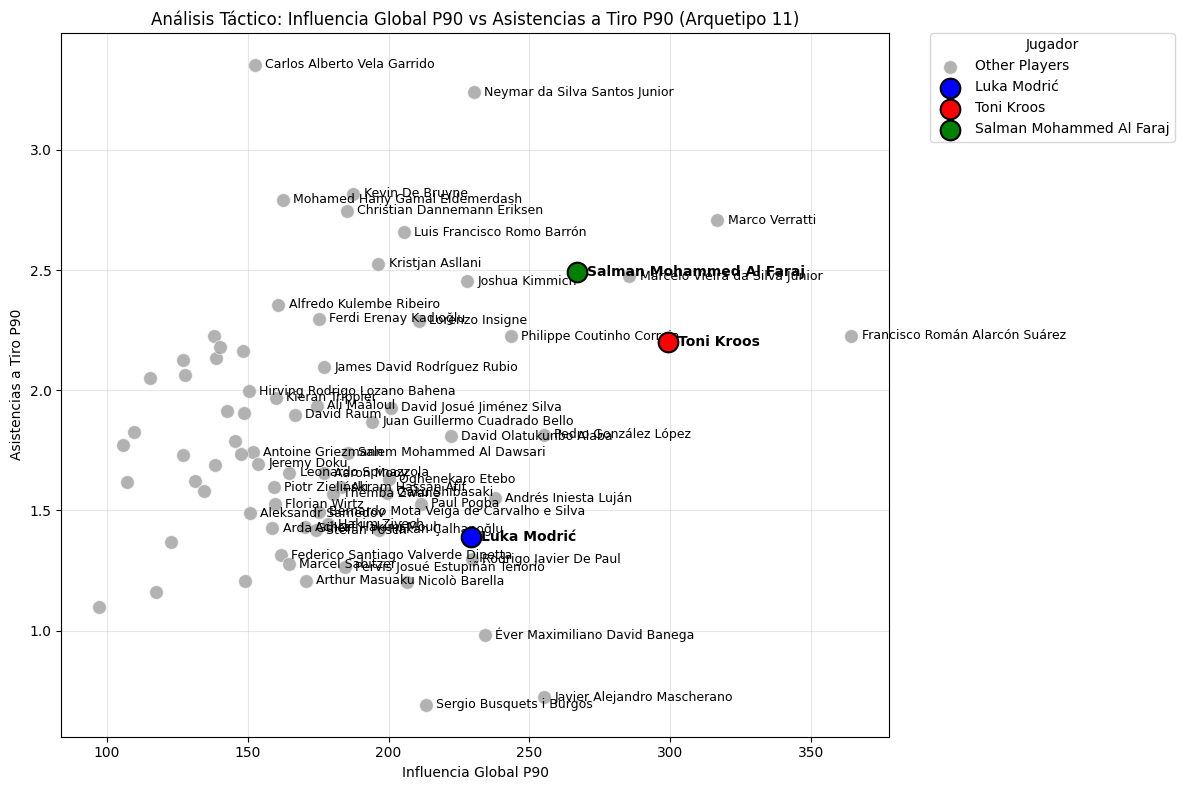

In [109]:
df_maestro = pd.read_csv('Master_Dataset_Scouting (3).csv')

def plot_archetype_scatter(df, archetype_id, x_var, y_var, title, x_label, y_label, annotation_threshold_x=None, highlight_colors=None):
    cluster_data = df[df['Arquetipo_SOM'] == archetype_id]
    plt.figure(figsize=(12, 8))

    if highlight_colors:
        non_highlighted_players_data = cluster_data[~cluster_data['player'].isin(highlight_colors.keys())]
        sns.scatterplot(data=non_highlighted_players_data, x=x_var, y=y_var, s=100, color='grey', label='Other Players', alpha=0.6)
    else:
        sns.scatterplot(data=cluster_data, x=x_var, y=y_var, s=100, color='grey', label='All Players', alpha=0.6)

    if highlight_colors:
        for player_name, color in highlight_colors.items():
            if player_name in cluster_data['player'].values:
                player_data = cluster_data[cluster_data['player'] == player_name].head(1)
                sns.scatterplot(data=player_data, x=x_var, y=y_var, s=200, color=color, label=player_name, edgecolor='black', linewidth=1.5, zorder=5) # zorder to ensure they are on top

    annotated_players_names = set()
    if highlight_colors:
        for player_name in highlight_colors.keys():
            if player_name in cluster_data['player'].values:
                player_data = cluster_data[cluster_data['player'] == player_name].iloc[0] # Get the first row as a Series for text annotation
                plt.text(player_data[x_var] + (cluster_data[x_var].max() * 0.01),
                         player_data[y_var],
                         player_data['player'], fontsize=10, ha='left', va='center', weight='bold')
                annotated_players_names.add(player_name)

    if annotation_threshold_x is not None:
        players_to_annotate = cluster_data[cluster_data[x_var] > annotation_threshold_x]
        for i, row in players_to_annotate.iterrows():
            if row['player'] not in annotated_players_names:
                plt.text(row[x_var] + (cluster_data[x_var].max() * 0.01),
                         row[y_var],
                         row['player'], fontsize=9, ha='left', va='center')

    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.grid(True, alpha=0.3)

    plt.legend(title='Jugador', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout()
    plt.show()

archetype_id_to_plot = 11 #
x_variable_to_plot = 'Influencia Global P90_Crudo'
y_variable_to_plot = 'Asistencias a Tiro P90_Crudo'

plot_title = f"Análisis Táctico: {x_variable_to_plot.replace('_Crudo', '')} vs {y_variable_to_plot.replace('_Crudo', '')} (Arquetipo {archetype_id_to_plot})"
x_axis_label = x_variable_to_plot.replace('_Crudo', '')
y_axis_label = y_variable_to_plot.replace('_Crudo', '')


annotation_threshold = 150

highlight_players_colors = {
    'Luka Modrić': 'blue',
    'Toni Kroos': 'red',
    'Salman Mohammed Al Faraj': 'green'
}

plot_archetype_scatter(
    df_maestro,
    archetype_id_to_plot,
    x_variable_to_plot,
    y_variable_to_plot,
    plot_title,
    x_axis_label,
    y_axis_label,
    annotation_threshold,
    highlight_colors=highlight_players_colors
)

### 📊 SALMAN AL FARAJ VS LA ÉLITE (KROOS Y MODRIĆ)
*El gráfico de dispersión anterior aisló al jugador saudí, Salman Mohammed Al Faraj, en la esquina superior derecha del cuadrante. Una comparación directa de sus métricas P90 contra dos estrellas mundiales de enorme renombre, como Toni Kroos y Luka Modrić, revela por qué el algoritmo los considera pares tácticos, exponiendo una verdadera oportunidad de mercado.*

**1. Superando a la élite en Generación de Peligro**
Sorprendentemente, el jugador de menor renombre domina en la zona de finalización. Al Faraj registra el mayor volumen de **Asistencias a Tiro P90 (2.49)**, superando el excelente registro de Kroos (2.20) y casi duplicando a Modrić (1.39). Además, la calidad de sus propias ocasiones es superior: su **xG por Tiro (0.32)** destroza los registros de los europeos (0.22 y 0.05), demostrando una toma de decisiones de disparo sumamente eficiente.

**2. El Equilibrio Defensivo**
En la fase de destrucción, Al Faraj demuestra ser un mediocampista total. Registra **1.94 Intercepciones P90**, superando tanto a Kroos (1.65) como a Modrić (1.48). Aunque Modrić lidera las Recuperaciones puras (5.61), el registro de Al Faraj (5.26) lo mantiene sólidamente en el escalón de la élite defensiva de este arquetipo.

**3. El Dominio del Ritmo (La especialidad de Kroos)**
Donde la jerarquía europea se impone es en la base de la posesión. Toni Kroos demuestra por qué es el reloj del equipo con una **Influencia Global P90 de 299.27** y un asombroso **90.0% de Pases Exitosos**. Al Faraj logra una Influencia Global muy respetable de 266.95 (superando a Modrić), pero con un acierto de pase del 84.3%, propio de un jugador que asume mayores riesgos en el último tercio para generar volumen ofensivo.

**⚠️ Limitaciones y Contexto Competitivo (Reflexión Ética y de Datos)**
El modelo SOM ha detectado un talento puro de forma objetiva, pero el rigor estadístico exige contexto. En primer lugar, la métrica de tiempo: Al Faraj acumuló solo **325 minutos jugados**, frente a los 2005 de Modrić y los 1144 de Kroos, lo que indica una producción en ráfagas cortas. En segundo lugar, la calidad de la oposición: el jugador saudí no se enfrenta regularmente a rivales del mismo nivel de exigencia y renombre que los otros dos seleccionados mundiales.

Para una Secretaría Técnica, este hallazgo es invaluable no como una verdad absoluta, sino como **evidencia del potencial del algoritmo**. Demuestra que el modelo funciona perfectamente para identificar "clones tácticos", y deja claro que, al escalar este sistema a una base de datos más rica (por ejemplo, alimentándolo con estadísticas de ligas regulares que se disputan anualmente a lo largo de 38 jornadas), se podrían extraer interpretaciones de scouting mucho más robustas, profundas y definitivas para la toma de decisiones en el mercado de fichajes.

In [108]:
players_to_compare_corrected = ['Salman Mohammed Al Faraj', 'Toni Kroos', 'Luka Modrić']

raw_tactical_variables = [f'{var}_Crudo' for var in variables_tacticas]

comparison_table_corrected = df_maestro[df_maestro['player'].isin(players_to_compare_corrected)][['player', 'minutos_jugados'] + raw_tactical_variables]

display(comparison_table_corrected)

,player,minutos_jugados,xG P90_Crudo,xG por Tiro_Crudo,% Pases Bajo Presión_Crudo,Asistencias a Tiro P90_Crudo,% Pases Exitosos_Crudo,Intercepciones P90_Crudo,% Duelos Aéreos_Crudo,Recuperaciones P90_Crudo,Influencia Global P90_Crudo,Faltas Recibidas P90_Crudo
732,Luka Modrić,2005,0.268695,0.221701,0.049129,1.391521,0.838568,1.481297,0.812500,5.610973,229.331671,1.795511
1073,Salman Mohammed Al Faraj,325,0.268432,0.323113,0.047718,2.492308,0.843416,1.938462,1.500000,5.261538,266.953846,1.384615
1184,Toni Kroos,1144,0.089708,0.049578,0.047319,2.202797,0.899921,1.652098,3.833333,3.697552,299.265734,1.573427


### 🎯 CONCLUSIÓN EJECUTIVA: EL FUTURO DEL SCOUTING
El objetivo de este proyecto no era simplemente agrupar estadísticas, sino responder a una pregunta crítica en el fútbol moderno: **¿Podemos encontrar ineficiencias en el mercado aislando el rendimiento táctico del sesgo mediático?**

La respuesta de nuestro modelo de Inteligencia Artificial (SOM) es un rotundo sí. Al transformar eventos aislados en una matriz de "ADN Táctico", demostramos que:
1. **Los arquetipos trascienden las posiciones:** Un defensa central y un mediocampista pueden compartir el mismo rol de "Constructor" en la salida de balón.
2. **El talento oculto es cuantificable:** El caso de Salman Al Faraj demuestra que, controlando las variables de volumen y contexto, es posible identificar perfiles de "Clase Mundial" fuera de las cinco grandes ligas europeas.

**El Mensaje Final**
Los datos no reemplazan la intuición del *scouting* tradicional ni al Director Deportivo, pero proporcionan un filtro inicial implacable. En un mercado donde los clubes pagan primas millonarias por el nombre de un jugador, este enfoque analítico permite fichar rendimiento táctico comprobado a una fracción del costo. Esta es la verdadera ventaja competitiva del análisis de datos en el deporte.